In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import time
import copy
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
plt.style.use("labor.mplstyle")
plt.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}
"""
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.ioff()
import ipywidgets as widgets
import IPython.display as display
from PIL import Image

# Load classes and definitions
import global_definitions
import data_loader
import data_preprocessing
import convert_data
import fit_models
import fits
import plots
import fit_rbm_params

In [3]:
""" Notes (labram / LabSpec):
Tresholds: 458nm: 18.7A, and: not working: 532nm (>28A needed) and 647nm (22-26A or higher needed)
-) Labram: -120 to -122 degree cooled down (Nitrogen) / 405-Setup: -65 degree 
-) 405-Setup: (final measurement) with slit at 2 (ask Laura: should mean 5 is max - 25 nm, so 2 means 2/5*25nm ?)
-) Labram: X50 Vergrößerung / 405-Setup: X10 Vergrößerung
"""
files_and_descriptions = [
    # label, wavelength, nm/cm-1, file, exposure-time, repetitions, power-mW, Ampere-laser, Hole [um], Slit [um], Resolution LabRam 600 and 1800 [lines/mm], x-invert
    # 1) total time = acqu-time * rep, 
    # 2) "0" means not specified
    #['488-1',488,'cm-1','488-1.txt',    40,  10, 14.3, 32, 1000, 300, 600,-40, 40, False],#
    #['488-2',488,'cm-1','488-2.txt',    20,  20, 14.3, 24, 1000, 300, 600,-40, 40, False],#
    ['488-3',488,'cm-1','488-3.txt',    40,  50, 14.3, 24, 1000, 300, 1800,-13,47, True],# 
    #['515-1',515,'cm-1','515-1.txt',    10,  10, 14.3, 28, 1000, 300, 600,-40, 40, False],#
    #['515-2',515,'cm-1','515-2.txt',    20,  20, 14.3, 24, 1000, 300, 600,-40, 40, False],#
    ['515-3',515,'cm-1','515-3.txt',    40,  50, 14.3, 24, 1000, 300, 1800,-18,42, True],#
    #['568-1',568,'cm-1','568-1.txt',    20,  10, 7.5,  27, 1000, 300, 600,-40, 40, False],#
    #['568-2',568,'cm-1','568-2.txt',    20,  20, 14.3, 28, 1000, 300, 600,-40, 40, False],#
    ['568-3',568,'cm-1','568-3.txt',    40,  50, 14.3, 28, 1000, 300, 1800,-24,36, True],#
    #['633-1',633,'cm-1','633-1.txt',    10,  10, 3.4,  0,  1000, 300, 600,-40, 40, False],#
    #['633-2',633,'cm-1','633-2.txt',    20,  20, 14.3, 0, 1000, 300, 600,-40,  40, False],#
    ['633-3',633,'cm-1','633-3.txt',    40,  50, 14.3, 0, 1000, 300, 1800,-33, 27, True],#
]# HeNe, ArKr, ...
labels = [i[0] for i in [r[0:1] for r in files_and_descriptions]]
def temp(i,j):
    return [r[i:j] for r in files_and_descriptions]
def temp_(i,j):
    return np.array(temp(i,j),dtype=np.float64).T[0]
def temp__(i,j):
    return [i[0] for i in temp(i,j)]
wavelengths = temp_(1,2)
units_x = temp__(2,3)
files = temp__(3,4)
exposure_time = temp_(4,5)
repetitions = temp_(5,6)
laser_power_mW = temp_(6,7)
laser_power_A = temp_(7,8)
hole = temp_(8,9)
slit = temp_(9,10)
resolution = temp_(10,11)
rayleigh_xmin = temp_(11,12)
rayleigh_xmax = temp_(12,13)
x_invert = temp__(13,14)
data = [None]*len(files)

In [4]:
settings = pd.DataFrame({
    'wavelength': wavelengths,
    'units_x_file': units_x,
    'file': files,
    'exposure_time': exposure_time,
    'repetitions': repetitions,
    'laser_power_mW': laser_power_mW,
    'laser_power_A': laser_power_A,
    'hole': hole,
    'slit': slit,
    'resolution': resolution,
    'rayleigh-xmin':rayleigh_xmin,
    'rayleigh-xmax':rayleigh_xmax,
    'x_invert':x_invert
}, index=labels)
settings

,wavelength,units_x_file,file,exposure_time,repetitions,laser_power_mW,laser_power_A,hole,slit,resolution,rayleigh-xmin,rayleigh-xmax,x_invert
488-3,488.0,cm-1,488-3.txt,40.0,50.0,14.3,24.0,1000.0,300.0,1800.0,-13.0,47.0,True
515-3,515.0,cm-1,515-3.txt,40.0,50.0,14.3,24.0,1000.0,300.0,1800.0,-18.0,42.0,True
568-3,568.0,cm-1,568-3.txt,40.0,50.0,14.3,28.0,1000.0,300.0,1800.0,-24.0,36.0,True
633-3,633.0,cm-1,633-3.txt,40.0,50.0,14.3,0.0,1000.0,300.0,1800.0,-33.0,27.0,True


In [5]:
for idx in settings.index:
    settings.loc[idx, 'file'] = global_definitions.paths['bg_removed_RBM']+'/'+settings.loc[idx, 'file']
for i,(label,unit_x) in enumerate(zip(labels,units_x)):
    data[i] = data_loader.load_data(settings['file'][label], path=global_definitions.paths['data'])
data = {settings.index[i]: data[i] for i in range(settings.shape[0])}
settings

,wavelength,units_x_file,file,exposure_time,repetitions,laser_power_mW,laser_power_A,hole,slit,resolution,rayleigh-xmin,rayleigh-xmax,x_invert
488-3,488.0,cm-1,bg_removed_RBM/488-3.txt,40.0,50.0,14.3,24.0,1000.0,300.0,1800.0,-13.0,47.0,True
515-3,515.0,cm-1,bg_removed_RBM/515-3.txt,40.0,50.0,14.3,24.0,1000.0,300.0,1800.0,-18.0,42.0,True
568-3,568.0,cm-1,bg_removed_RBM/568-3.txt,40.0,50.0,14.3,28.0,1000.0,300.0,1800.0,-24.0,36.0,True
633-3,633.0,cm-1,bg_removed_RBM/633-3.txt,40.0,50.0,14.3,0.0,1000.0,300.0,1800.0,-33.0,27.0,True


In [6]:
# delete one disgusting point...
data_ = data['568-3']
x = np.array([d[0] for d in data_], dtype=np.float64)
y = np.array([d[1] for d in data_], dtype=np.float64)
idx = np.where(y<0.01)
x = np.delete(x, idx)
y = np.delete(y, idx)
data['568-3'] = np.column_stack((x, y))

# 1) Raw RBM (file label: 3) data

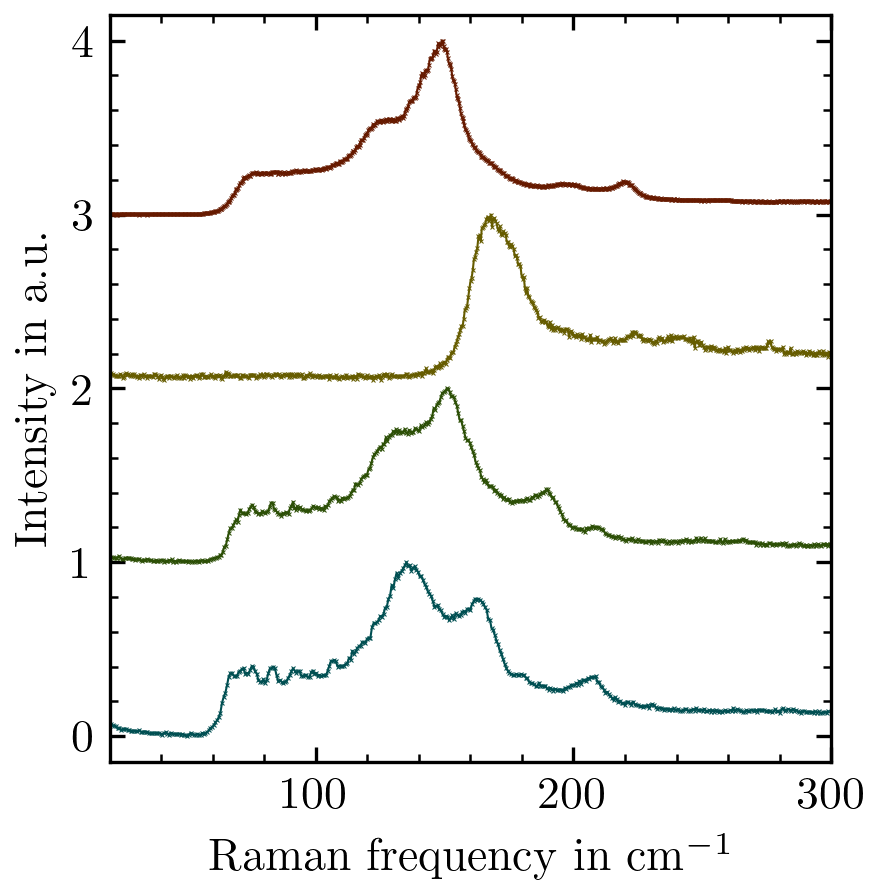

In [7]:
plots.RBM_split(data, wavelengths=settings['wavelength'].values, plot_range=[20, 300], rescale='local')
# G+, G- list, but important is Delta_G vs wavelength to plot

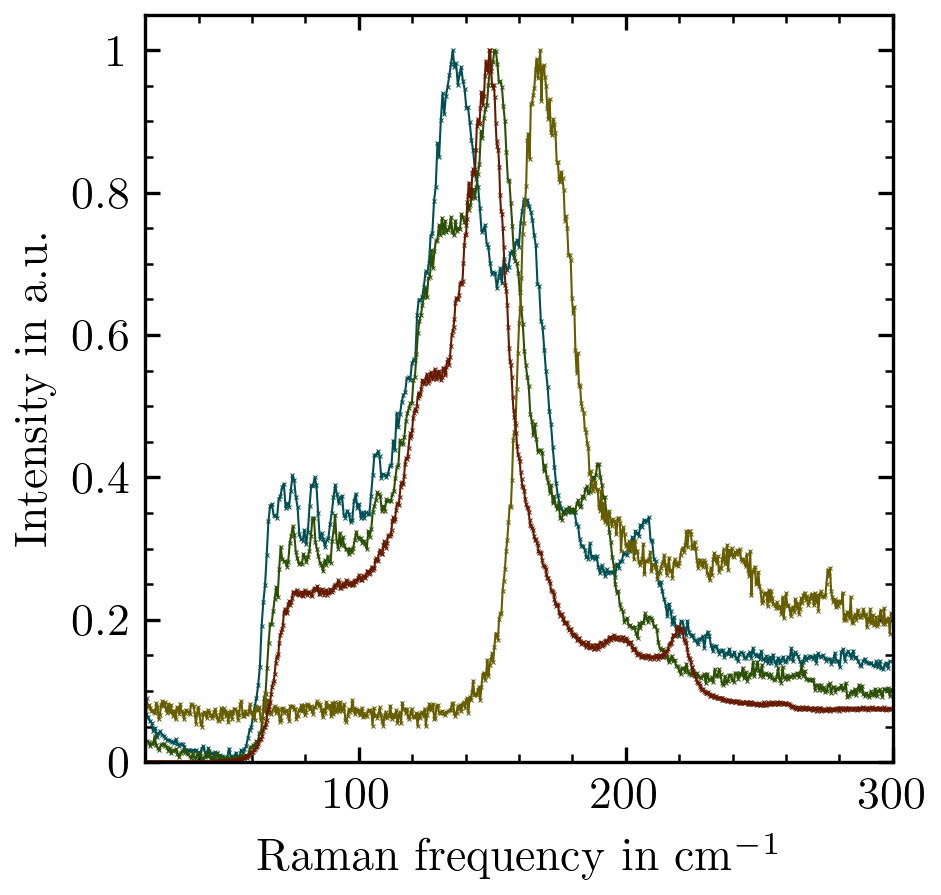

In [8]:
plots.RBM(data, wavelengths=settings['wavelength'].values, plot_range=[20, 300], rescale='local')

# 3) Main Program:
Now run the following code for each wavelength below to get the plots. (Save data for LaTeX bar plot.)

[5.00e-02 3.00e-02 2.50e+02 5.00e+00 3.00e-02 2.55e+02 5.00e+00 3.00e-02
 2.60e+02 5.00e+00 3.00e-02 2.80e+02 5.00e+00 4.00e-02 1.70e+02 5.00e+00
 4.00e-02 1.71e+02 5.00e+00 4.00e-02 1.72e+02 5.00e+00 4.00e-02 1.75e+02
 5.00e+00 4.00e-02 1.78e+02 5.00e+00 4.00e-02 1.80e+02 5.00e+00 4.00e-02
 2.00e+02 5.00e+00 4.00e-02 2.02e+02 5.00e+00 4.00e-02 2.04e+02 5.00e+00
 4.00e-02 2.16e+02 5.00e+00 4.00e-02 2.22e+02 5.00e+00 4.00e-02 1.43e+02
 5.00e+00 4.00e-02 1.42e+02 5.00e+00 4.00e-02 1.41e+02 5.00e+00 4.00e-02
 1.40e+02 5.00e+00 4.00e-02 1.34e+02 5.00e+00 4.00e-02 1.32e+02 5.00e+00
 4.00e-02 1.28e+02 5.00e+00 4.00e-02 8.20e+01 5.00e+00 4.00e-02 8.50e+01
 5.00e+00 4.00e-02 9.50e+01 5.00e+00 4.00e-02 1.00e+02 5.00e+00 4.00e-02
 1.02e+02 5.00e+00 4.00e-02 1.04e+02 5.00e+00 4.00e-02 1.06e+02 5.00e+00
 4.00e-02 1.08e+02 5.00e+00 4.00e-02 1.10e+02 5.00e+00 4.00e-02 1.12e+02
 5.00e+00]
[ 0.064]
[ 0.004  242.514  10.548]
[ 0.006  256.167  3.952]
[ 0.004  260.201  1.615]
[ 0.006  290.000  15.000]
[ 

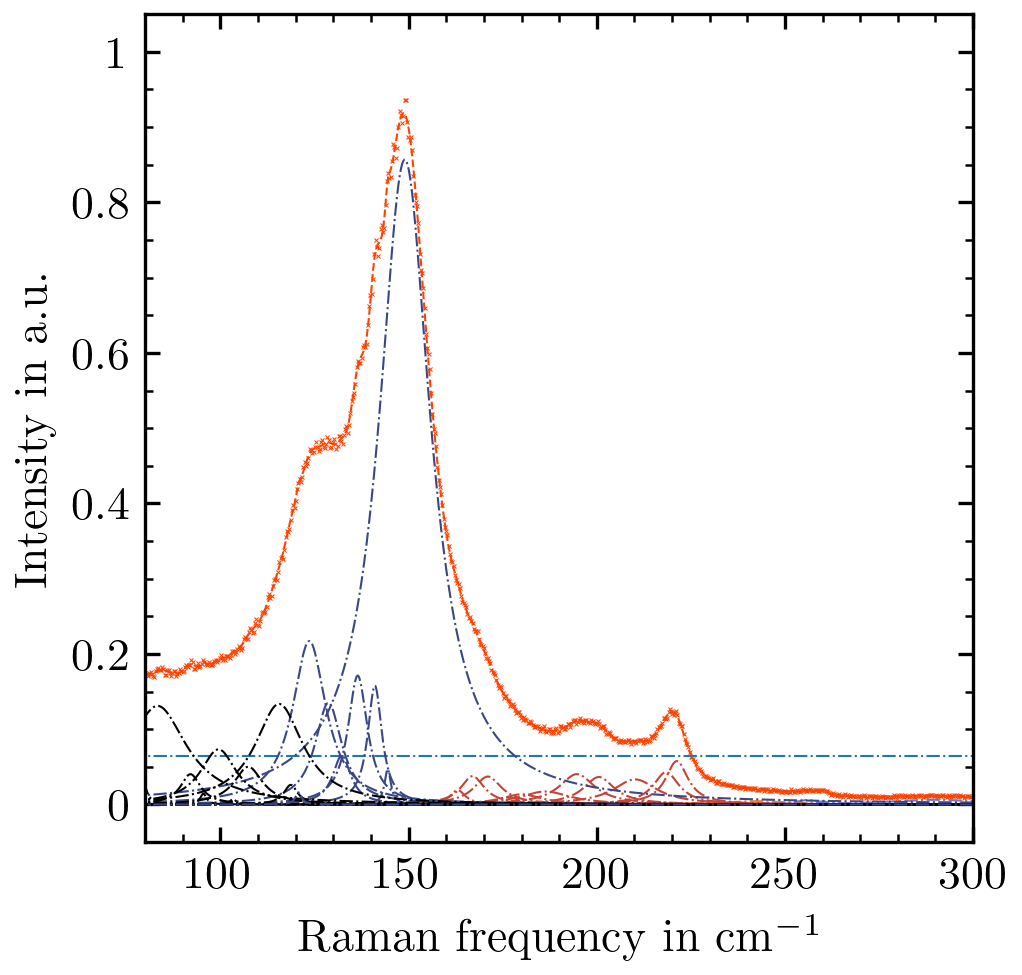

In [9]:
# define figure
fig, ax = plt.subplots(layout="constrained")

file_ = '633-3'
data_ = data[file_]
# separate data
x = np.array([d[0] for d in data_], dtype=np.float64)
y = np.array([d[1] for d in data_], dtype=np.float64)

# fit
x_fit = x
x_min = 80
x_max = 300
comp_model, res_fit,x_r,y_r = fits.RBM_lines(data_, 
    exclude=[[-10000,x_min],[x_max,10000]], 
    model_types=['polynomial','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian'],#, 'gaussian'],
    inits=fit_rbm_params.inits[file_],
    sigma=15,
    normalize=True
)
ax.plot(x_r,y_r-comp_model.get_params(separate=True)[0],linestyle='',color=global_definitions.col_nm['633'])

fit_funcs = comp_model.get_fit_func(separate=True)
y_fits = np.zeros((len(fit_funcs),len(x_fit)))
for i,f in enumerate(fit_funcs):
    y_fits[i] = f(x_fit, *comp_model.get_params(separate=True)[i])
y_fit = comp_model.get_fit_func()(x_fit, *comp_model.get_params())

col = [None]*len(y_fits)
for i,y_ in enumerate(y_fits):
    if i >= 1:
        w = comp_model.get_params(separate=True)[i][1]
        if w <= 120:
            col[i] = global_definitions.col_rbm['1']
        if w > 120 and w <= 160:
            col[i] = global_definitions.col_rbm['2']
        if w > 160 and w <= 230:
            col[i] = global_definitions.col_rbm['3']
        if w > 230:
            col[i] = global_definitions.col_rbm['4']

ax.plot(x_fit,y_fit-comp_model.get_params(separate=True)[0],linestyle='--',marker='',color=global_definitions.col_nm['633'])
for i,y_ in enumerate(y_fits):
    if i>1:
        ax.plot(x_fit,y_,linestyle='-.',marker='',color=col[i])
    else:
        ax.plot(x_fit,y_,linestyle='-.',marker='')

y_max = 1.05
ax.set_ylim(-0.05, y_max)
ax.set_xlim(x_min, x_max)
ax.set_aspect((x_max - x_min)/(y_max+0.05))
ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_xlabel(r'Raman frequency in \unit{\per\centi\metre}')
ax.set_ylabel(r'Intensity in a.u.')
plt.show()

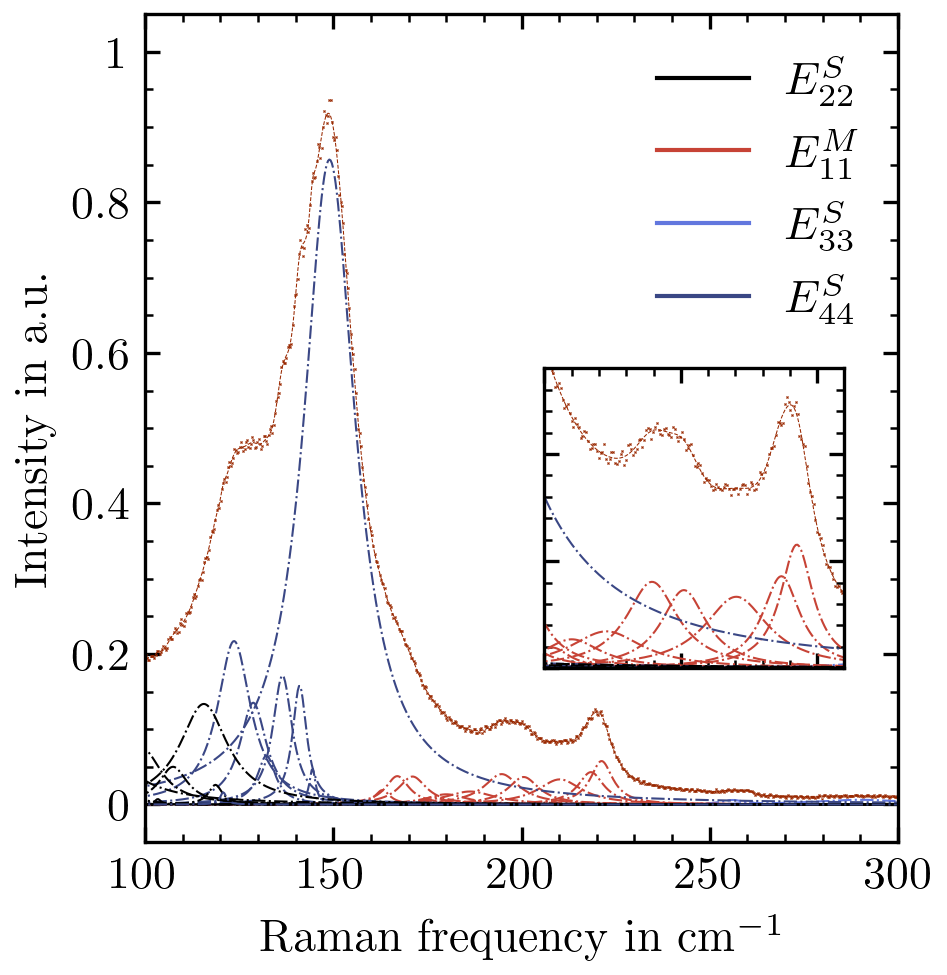

In [10]:
fig, ax = plt.subplots(layout="constrained")
col_ = plots.color_selector(dict({file_[:3]+'-2':data[file_]}))[0]
ax.plot(x_r,y_r-comp_model.get_params(separate=True)[0],linestyle='',markersize=0.5,color=col_)
ax.plot(x_fit,y_fit-comp_model.get_params(separate=True)[0],linestyle='--',linewidth=0.25,marker='',color=col_)
for i,y_ in enumerate(y_fits):
    if i>1:
        ax.plot(x_fit,y_,linestyle='-.',marker='',color=col[i])
    #elif i>0:
    #    ax.plot(x_fit,y_,linestyle='-.',marker='',color='k')

col_un = list(set(col))[1:]
col_un = [col_un[i] for i in [0,3,1,2]]
labels = [r'$E_{22}^S$',r'$E_{11}^M$',r'$E_{33}^S$',r'$E_{44}^S$']
# dummy for label
for i, (label) in enumerate(labels):
    ax.plot([],[], linestyle="-", marker='', linewidth=1, markersize=5, color=col_un[i], label=label)

ax_legend = ax.legend(loc='upper right')
for legobj in ax_legend.legend_handles:
    legobj.set_linewidth(1)




axin = inset_axes(ax, width=1*1, height=1*1, 
                          bbox_to_anchor=(0.5, 0, 1, 0.6),
                          bbox_transform=ax.transAxes, loc=2)
axin.plot(x_r,y_r-comp_model.get_params(separate=True)[0],linestyle='',markersize=0.5,color=col_)
axin.plot(x_fit,y_fit-comp_model.get_params(separate=True)[0],linestyle='--',linewidth=0.25,marker='',color=col_)
for i,y_ in enumerate(y_fits):
    if i>=1:
        axin.plot(x_fit,y_,linestyle='-.',marker='',color=col[i])
    #else:
    #    ax.plot(x_fit,y_,linestyle='-.',marker='',color='b')

y_max = 0.14#0.14
axin.set_ylim(0., y_max)
axin.set_xlim(175, 230)#180
axin.set_aspect((230 - 175)/(y_max-0.))
axin.tick_params(axis='y',which='both',labelleft=False)
axin.tick_params(axis='x',which='both',labelbottom=False)

y_max = 1.05
ax.set_ylim(-0.05, y_max)
ax.set_xlim(100, x_max)
ax.set_aspect((x_max - x_min)/(y_max+0.05))
ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_xlabel(r'Raman frequency in \unit{\per\centi\metre}')
ax.set_ylabel(r'Intensity in a.u.')
plt.savefig(global_definitions.paths['plots']+'/'+'RBM_'+file_+'.png')
plt.show()

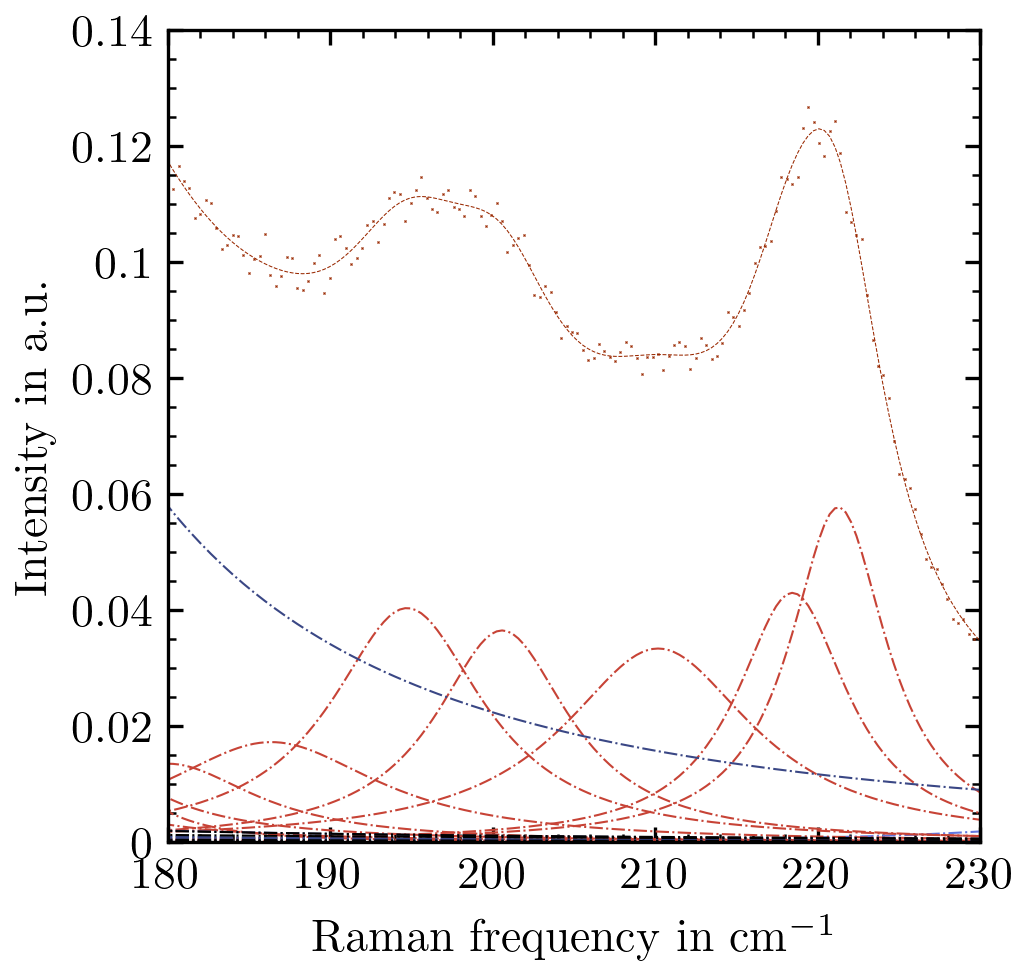

In [11]:
fig, ax = plt.subplots(layout="constrained")

ax.plot(x_r,y_r-comp_model.get_params(separate=True)[0],linestyle='',markersize=0.5,color=col_)
ax.plot(x_fit,y_fit-comp_model.get_params(separate=True)[0],linestyle='--',linewidth=0.25,marker='',color=col_)
for i,y_ in enumerate(y_fits):
    if i>=1:
        ax.plot(x_fit,y_,linestyle='-.',marker='',color=col[i])
    #else:
    #    ax.plot(x_fit,y_,linestyle='-.',marker='',color='b')

y_max = 0.14#0.14
ax.set_ylim(0., y_max)
ax.set_xlim(180, 230)#180
ax.set_aspect((230 - 180)/(y_max-0.))
ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_xlabel(r'Raman frequency in \unit{\per\centi\metre}')
ax.set_ylabel(r'Intensity in a.u.')
plt.show()

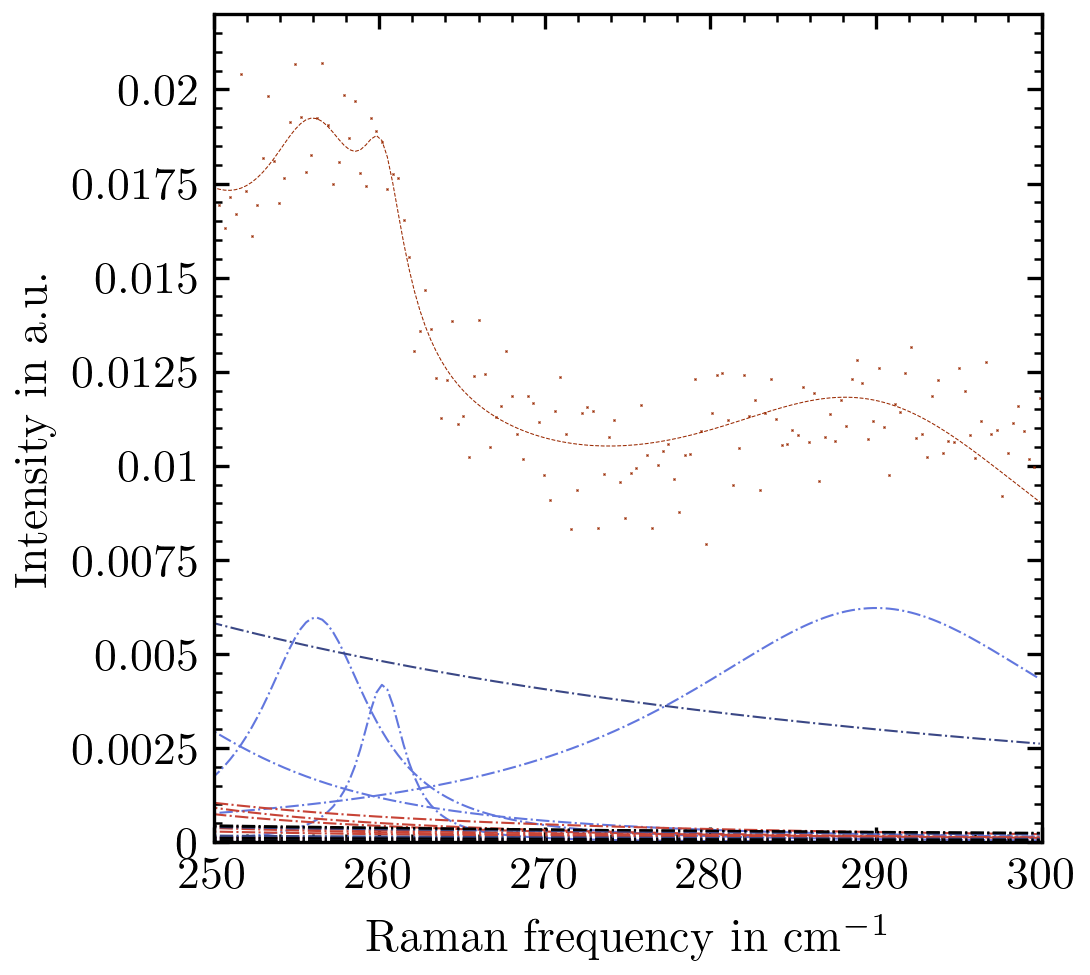

In [12]:
fig, ax = plt.subplots(layout="constrained")

ax.plot(x_r,y_r-comp_model.get_params(separate=True)[0],linestyle='',markersize=0.5,color=col_)
ax.plot(x_fit,y_fit-comp_model.get_params(separate=True)[0],linestyle='--',linewidth=0.25,marker='',color=col_)
for i,y_ in enumerate(y_fits):
    if i>=1:
        ax.plot(x_fit,y_,linestyle='-.',marker='',color=col[i])
    #else:
    #    ax.plot(x_fit,y_,linestyle='-.',marker='',color='b')

y_max = 0.022
ax.set_ylim(0., y_max)
ax.set_xlim(250, 300)
ax.set_aspect((300 - 250)/(y_max-0.))
ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_xlabel(r'Raman frequency in \unit{\per\centi\metre}')
ax.set_ylabel(r'Intensity in a.u.')
plt.show()

In [13]:
e_ = convert_data.nm_to_eV(wavelengths)
e_s = [r'{0:.2f}'.format(e) for e in e_]

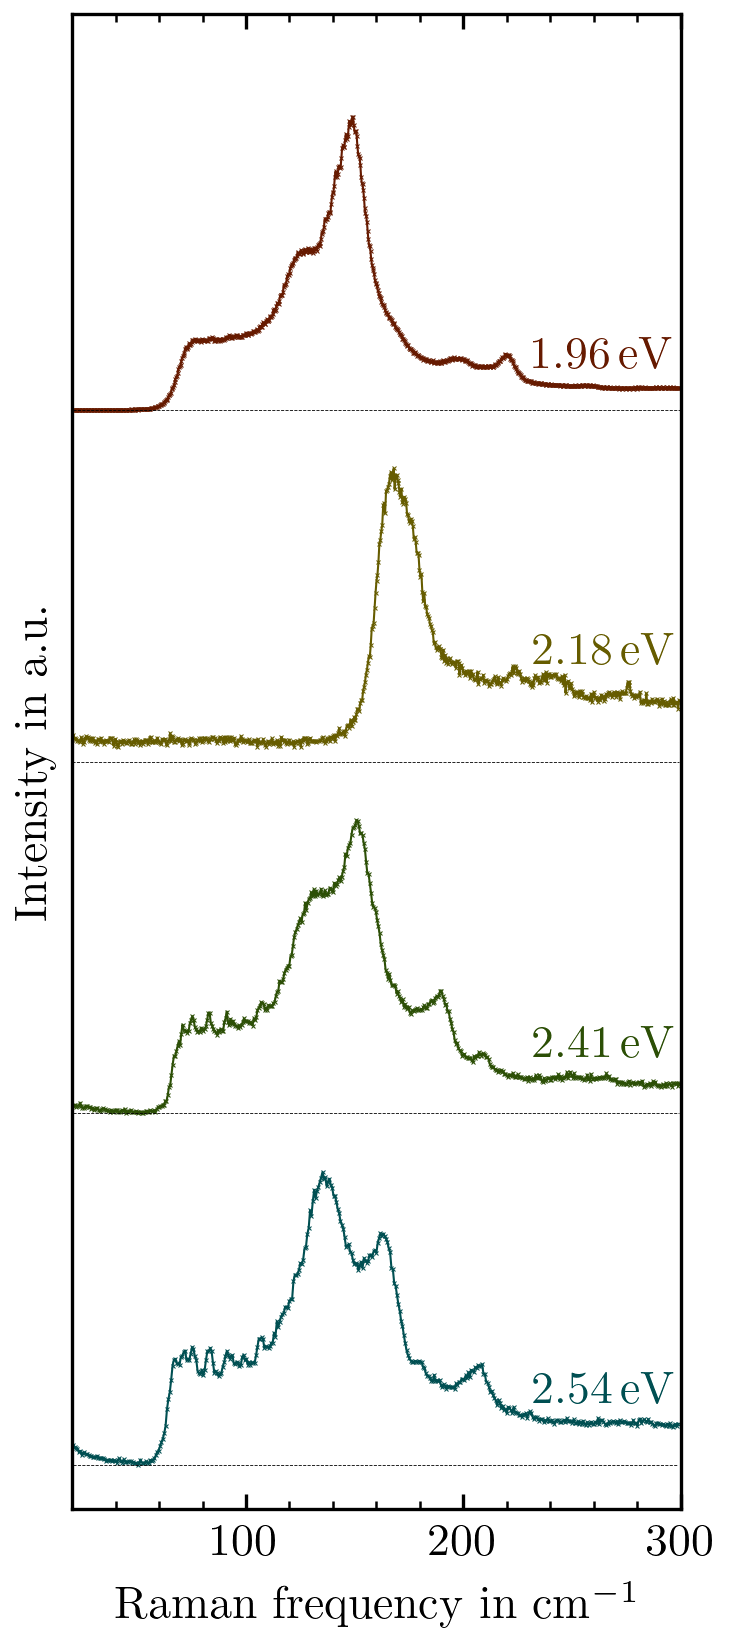

In [14]:
plots.RBM_split_plt(data,labels=[[265]*len(wavelengths),e_s], wavelengths=settings['wavelength'].values, plot_range=[20, 300], rescale='local')
# G+, G- list, but important is Delta_G vs wavelength to plot

In [15]:
import fit_rbm_params

[ 0.050  0.030  250.000  5.000  0.030  255.000  5.000  0.030  260.000
  5.000  0.030  280.000  5.000  0.040  170.000  5.000  0.040  171.000
  5.000  0.040  172.000  5.000  0.040  175.000  5.000  0.040  178.000
  5.000  0.040  180.000  5.000  0.040  200.000  5.000  0.040  202.000
  5.000  0.040  204.000  5.000  0.040  216.000  5.000  0.040  222.000
  5.000  0.040  143.000  5.000  0.040  142.000  5.000  0.040  141.000
  5.000  0.040  140.000  5.000  0.040  134.000  5.000  0.040  132.000
  5.000  0.040  128.000  5.000  0.040  82.000  5.000  0.040  85.000  5.000
  0.040  95.000  5.000  0.040  100.000  5.000  0.040  102.000  5.000
  0.040  104.000  5.000  0.040  106.000  5.000  0.040  108.000  5.000
  0.040  110.000  5.000  0.040  112.000  5.000]
[ 0.119]
[ 0.005  249.463  4.084]
[ 0.007  247.657  1.000]
[ 0.011  262.673  1.908]
[ 0.020  280.880  15.000]
[ 0.033  161.920  1.000]
[ 0.079  169.911  2.892]
[ 0.316  162.000  8.668]
[ 0.159  165.179  3.561]
[ 0.071  180.326  2.902]
[ 0.044  187.

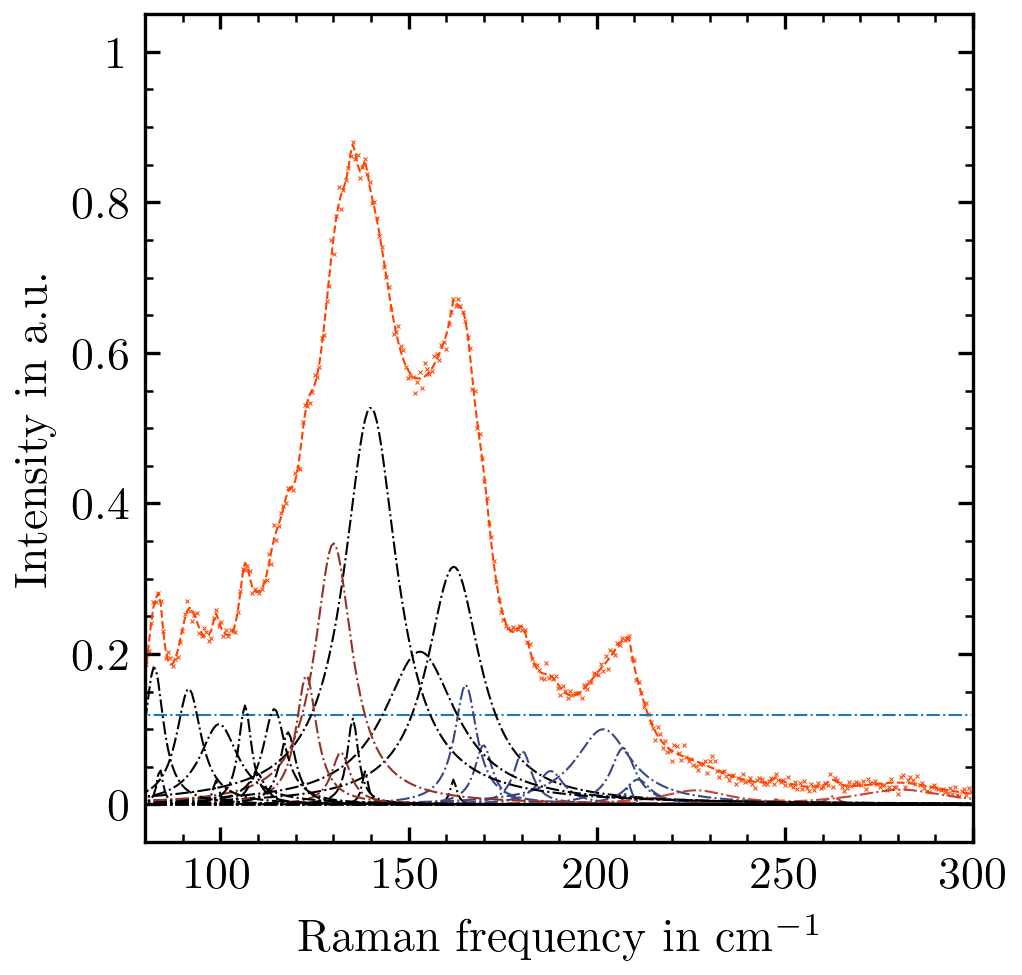

In [16]:
# define figure
fig, ax = plt.subplots(layout="constrained")

file_ = '488-3'
data_ = data[file_]
# separate data
x = np.array([d[0] for d in data_], dtype=np.float64)
y = np.array([d[1] for d in data_], dtype=np.float64)

# fit
x_fit = x
x_min = 80
x_max = 300
comp_model, res_fit,x_r,y_r = fits.RBM_lines(data_, 
    exclude=[[-10000,x_min],[x_max,10000]], 
    model_types=['polynomial','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian','lorentzian'],#, 'gaussian'],
    inits=fit_rbm_params.inits[file_],
    sigma=15,
    normalize=True
)
ax.plot(x_r,y_r-comp_model.get_params(separate=True)[0],linestyle='',color=global_definitions.col_nm['633'])

fit_funcs = comp_model.get_fit_func(separate=True)
y_fits = np.zeros((len(fit_funcs),len(x_fit)))
for i,f in enumerate(fit_funcs):
    y_fits[i] = f(x_fit, *comp_model.get_params(separate=True)[i])
y_fit = comp_model.get_fit_func()(x_fit, *comp_model.get_params())

col = [None]*len(y_fits)
for i,y_ in enumerate(y_fits):
    if i >= 1:
        w = comp_model.get_params(separate=True)[i][1]
        if w <= 120:
            col[i] = global_definitions.col_rbm_['1']
        if w > 120 and w <= 135:
            col[i] = global_definitions.col_rbm_['2']
        if w > 135 and w <= 165:
            col[i] = global_definitions.col_rbm_['3']
        if w > 165 and w <= 215:
            col[i] = global_definitions.col_rbm_['4']
        if w > 215:
            col[i] = global_definitions.col_rbm_['5']

ax.plot(x_fit,y_fit-comp_model.get_params(separate=True)[0],linestyle='--',marker='',color=global_definitions.col_nm['633'])
for i,y_ in enumerate(y_fits):
    if i>1:
        ax.plot(x_fit,y_,linestyle='-.',marker='',color=col[i])
    else:
        ax.plot(x_fit,y_,linestyle='-.',marker='')

y_max = 1.05
ax.set_ylim(-0.05, y_max)
ax.set_xlim(x_min, x_max)
ax.set_aspect((x_max - x_min)/(y_max+0.05))
ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_xlabel(r'Raman frequency in \unit{\per\centi\metre}')
ax.set_ylabel(r'Intensity in a.u.')
plt.show()